In [1]:
from utils import Utils
import pandas as pd
# from stable_baselines3 import PPO
# from poe import PortfolioOptimizationEnv
# from stockstats import wrap
import matplotlib.pyplot as plt

In [2]:
# df = Utils.create_df("./d
# ata/anonymized_data/")
# pd.DataFrame(df).reset_index().to_csv("data/created_df.csv", index=False)
df = pd.read_csv("data/created_df.csv")
df["date"] = pd.to_datetime(df["date"])
n = 1
df = Utils.get_first_n_assets(df, n)
features = Utils.get_features(df).dropna()

In [3]:
features.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'log-ret',
       'rsi_6', 'rsi', 'cci_6', 'cci', 'dx', 'adx', 'adxr', 'close_5_sma',
       'close_20_ema', 'close_5_ema', 'cci_5', 'pdi', 'ndi', 'stochrsi_3',
       'macd', 'macds', 'macdh', 'tema', 'pvo', 'pvos', 'pvoh', 'volatility'],
      dtype='str')

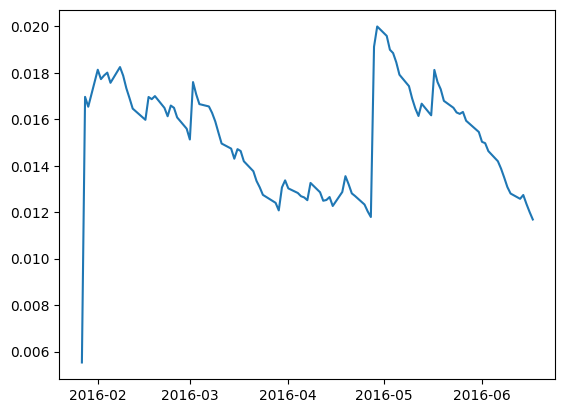

In [4]:
plt.plot(features['date'][:100], features['volatility'][:100])
plt.show()

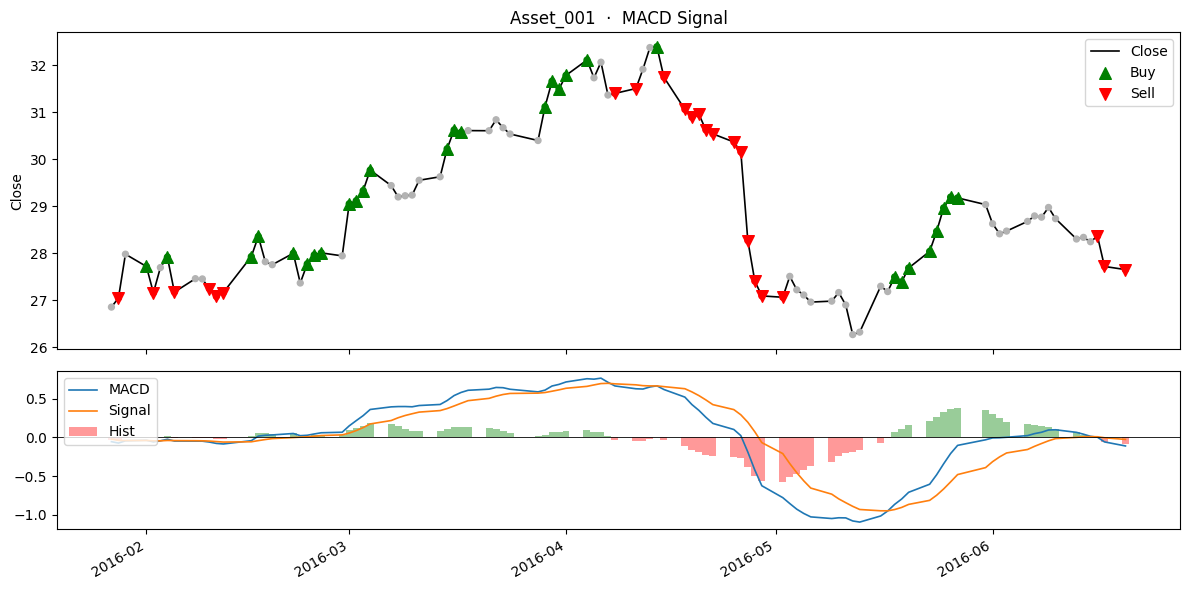

In [5]:
signal = pd.DataFrame()
signal['date'] = features['date']
one = features.reset_index(drop=True).copy()
one['macd_signal'] = Utils.get_macd_signal(one['macd'], one['macds'], one['macdh'])
signal['macd_signal'] = one['macd_signal']
sig = one['macd_signal']
label = "MACD Signal"

window = slice(None, 100)  # first 100 bars; use slice(None) for all
px = one.loc[window]
s = px['macd_signal']
dates = pd.to_datetime(px["date"])
close = px["close"]

buy = s == 1
sell = s == -1

fig, (ax, ax_m) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax.plot(dates, close, color="black", lw=1.2, label="Close")
ax.scatter(dates, close, c=["g" if v == 1 else "r" if v == -1 else "0.7" for v in s], s=18, zorder=3)
ax.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=4, label="Buy")
ax.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=4, label="Sell")
ax.set_title(f"{one['tic'].iloc[0]}  ·  {label}"); ax.set_ylabel("Close"); ax.legend()
ax_m.plot(dates, px["macd"], color="C0", lw=1.2, label="MACD"); ax_m.plot(dates, px["macds"], color="C1", lw=1.2, label="Signal")
ax_m.bar(dates, px["macdh"], color=["g" if v >= 0 else "r" for v in px["macdh"]], width=1.0, alpha=0.4, label="Hist")
ax_m.axhline(0, color="k", lw=0.6); ax_m.legend(loc="upper left")
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

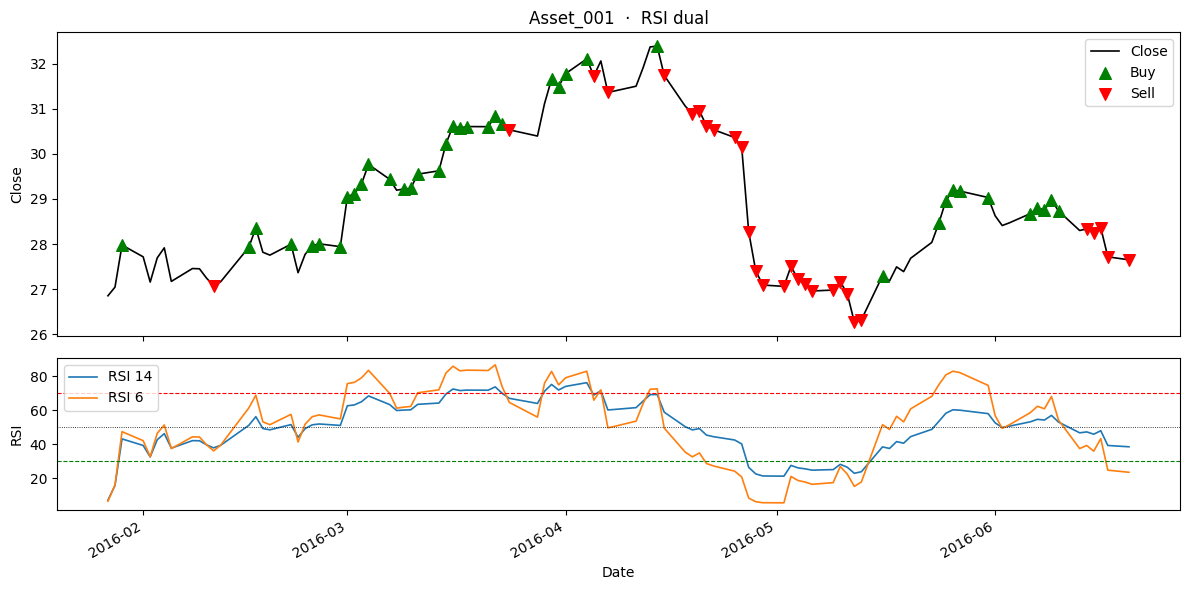

In [6]:
# one ticker is already in `features` (n = 1)
one = features.reset_index(drop=True).copy()
one['rsi_signal'] = Utils.get_rsi_signal(one["rsi"], one["rsi_6"])
signal['rsi_signal'] = one['rsi_signal']
rsi_sig = one['rsi_signal']
# macd_cross, macd_zero = Utils.get_macd_signal(one["macd"], one["macds"], one["macdh"])

# pick the series to draw: rsi_sig, macd_cross, or macd_zero
sig = rsi_sig
label = "RSI dual"

window = slice(None, 100)  # first 100 bars; use slice(None) for all
px = one.loc[window]
s = px['rsi_signal']
dates = pd.to_datetime(px["date"])
close = px["close"]

buy = s == 1
sell = s == -1

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax.plot(dates, close, color="black", lw=1.2, label="Close")
ax.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=3, label="Buy")
ax.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=3, label="Sell")
ax.set_title(f"{one['tic'].iloc[0]}  ·  {label}")
ax.set_ylabel("Close")
ax.legend()

ax_r.plot(dates, px["rsi"], color="C0", lw=1.2, label="RSI 14")
ax_r.plot(dates, px["rsi_6"], color="C1", lw=1.2, label="RSI 6")
ax_r.axhline(70, color="r", ls="--", lw=0.8)
ax_r.axhline(30, color="g", ls="--", lw=0.8)
ax_r.axhline(50, color="k", ls=":", lw=0.6)
ax_r.set_ylabel("RSI")
ax_r.set_xlabel("Date")
ax_r.legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

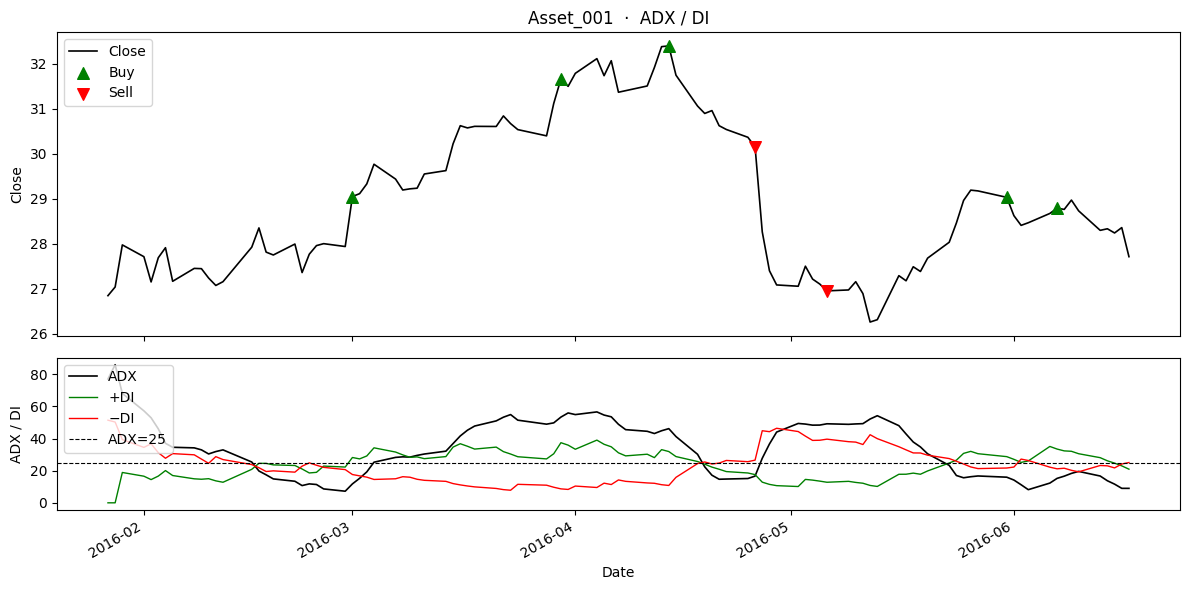

In [7]:
one = features.reset_index(drop=True).copy()
one["adx_signal"] = Utils.get_adx_signal(one)
signal["adx_signal"] = one["adx_signal"]
adx_sig = one["adx_signal"]
label = "ADX Signal"

window = slice(None, 100)
px = one.iloc[window]
s = px["adx_signal"]
changed = s != s.shift()
buy = (s == 1) & changed
sell = (s == -1) & changed
dates = pd.to_datetime(px["date"])
close = px["close"]

fig, (ax_px, ax_adx) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

ax_px.plot(dates, close, color="black", lw=1.2, label="Close")
ax_px.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=3, label="Buy")
ax_px.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=3, label="Sell")
ax_px.set_ylabel("Close")
ax_px.set_title(f"{one['tic'].iloc[0]}  ·  ADX / DI")
ax_px.legend(loc="upper left")

ax_adx.plot(dates, px["adx"], color="black", lw=1.2, label="ADX")
ax_adx.plot(dates, px["pdi"], color="green", lw=1.0, label="+DI")
ax_adx.plot(dates, px["ndi"], color="red", lw=1.0, label="−DI")
ax_adx.axhline(25, color="k", ls="--", lw=0.8, label="ADX=25")
ax_adx.set_ylabel("ADX / DI")
ax_adx.set_xlabel("Date")
ax_adx.legend(loc="upper left")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

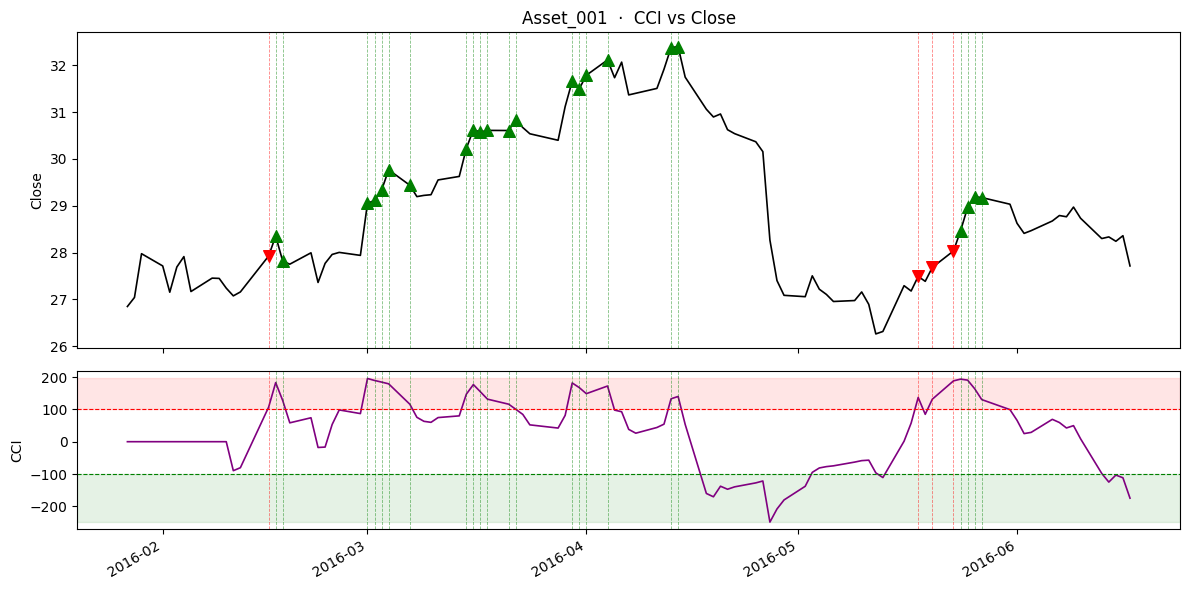

In [8]:
one = features.reset_index(drop=True).copy()
one["cci_signal"] = Utils.get_cci_signal(one["cci"], one["pdi"], one["ndi"])
window = slice(None, 100)
px = one.iloc[window]
dates = pd.to_datetime(px["date"])
s = px["cci_signal"]
buy, sell = s == 1, s == -1
fig, (ax_px, ax_cci) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax_px.plot(dates, px["close"], color="black", lw=1.2, label="Close")
ax_px.scatter(dates[buy], px.loc[buy, "close"], marker="^", s=70, color="green", zorder=3, label="Buy")
ax_px.scatter(dates[sell], px.loc[sell, "close"], marker="v", s=70, color="red", zorder=3, label="Sell")
ax_px.set_ylabel("Close")
ax_px.set_title(f"{one['tic'].iloc[0]}  ·  CCI vs Close")
ax_cci.plot(dates, px["cci"], color="purple", lw=1.2, label="CCI")
ax_cci.axhline(100, color="r", ls="--", lw=0.8)
ax_cci.axhline(-100, color="g", ls="--", lw=0.8)
ax_cci.axhspan(100, px["cci"].max(), color="r", alpha=0.1)
ax_cci.axhspan(px["cci"].min(), -100, color="g", alpha=0.1)
ax_cci.set_ylabel("CCI")
[ax.axvline(d, color="g" if b else "r", ls="--", lw=0.6, alpha=0.5) for ax in (ax_px, ax_cci) for d, b, se in zip(dates, buy, sell) if b or se]
fig.autofmt_xdate(); fig.tight_layout(); plt.show()


In [9]:
signals = Utils.rule_signals(features).reset_index()
rule_cols = [
    "adx_di_cross",
    "adx_regime",
    "macd_rsi",
    "trend_pullback",
    "cci_adx",
    "stochrsi_trend",
]
features = features.copy()
features = features.merge(signals[["date", "tic"] + rule_cols], on=["date", "tic"], how="left")
vote = features[rule_cols].sum(axis=1)
features["rule_signal"] = (vote > 0).astype("int8") - (vote < 0).astype("int8")

features["adx_signal"] = Utils.get_adx_signal(
    features["adx"], features["pdi"], features["ndi"]
)
features["cci_signal"] = Utils.get_cci_signal(
    features["cci"], features["pdi"], features["ndi"]
)
features["rsi_signal"] = Utils.get_rsi_signal(
    features["rsi"], features["rsi_6"]
)
features["macd_signal"] = Utils.get_macd_signal(
    features["macd"], features["macds"], features["macdh"]
)

base_cols = ["adx_signal", "macd_signal", "rsi_signal", "cci_signal"]
cols = base_cols + rule_cols + ["rule_signal"]
for c in (0, 0.001):
    print(f"cost={c}")
    print(pd.DataFrame({k: Utils.eval_signal(features, k, c) for k in cols}).T.round(3))

cost=0
                sharpe  ann_return  turnover/yr  hit_rate  time_in_mkt
adx_signal       0.162       0.035       46.302     0.513        0.519
macd_signal      0.040       0.009       87.582     0.513        0.533
rsi_signal      -0.067      -0.015       99.334     0.501        0.577
cci_signal       0.828       0.095       38.568     0.536        0.297
adx_di_cross    -0.586      -0.121       61.669     0.459        0.339
adx_regime      -0.267      -0.048       64.481     0.475        0.263
macd_rsi         0.459       0.096       69.503     0.512        0.356
trend_pullback  -0.569      -0.028       10.446     0.386        0.028
cci_adx         -0.104      -0.007       13.660     0.515        0.027
stochrsi_trend   0.405       0.020       10.646     0.528        0.021
rule_signal     -0.084      -0.017       70.709     0.480        0.308
cost=0.001
                sharpe  ann_return  turnover/yr  hit_rate  time_in_mkt
adx_signal      -0.054      -0.012       46.302     0.513  